In [2]:
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from pysheds.grid import Grid
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [3]:
# full 7-band spectrum at ~1.017m resolution (organic)
# to generate candidate anchor nodes
# spectral_nodes shape: (N, 7) -- all 7 bands, valid pixels only

# build 7-band array for valid pixels
# bands 1-5: spectral5_refl
# bands 6-7: aux2bands_arr (panc, lwir) -- need to normalize lwir

In [6]:
# load existing metas
valid_r = np.load('data/valid_r.npy')
valid_c = np.load('data/valid_c.npy')
spectral_valid_mask = np.load('data/spectral_valid_mask.npy')
valid_idx = np.where(valid_mask_np)[0]
print(f'valid_idx shape: {valid_idx.shape}')

valid_idx shape: (1988246,)


In [15]:
# reload raw spectral nodes for all 7 bands
with rasterio.open('data/CanwellTerminus081325.tif') as src:
    mosaic_raw = src.read().astype(np.float32)
    crs = src.crs

# apply reflectance scaling to bands 1-6 (not lwir)
SCALE = 32768.0
mosaic_refl = mosaic_raw.copy()
mosaic_refl[:6] = mosaic_raw[:6] / SCALE
# lwir stays in DN -- z-score later separately

# extract valid pixels for all 7 bands
vr_valid = valid_r[valid_idx]
vc_valid = valid_c[valid_idx]

spec7 = np.stack([
    mosaic_refl[b, vr_valid, vc_valid] for b in range(7)
], axis=1).astype(np.float32) # (N_valid, 7)

# normalize lwir to scale of reflectance bands
# z-score using valid pixel stats
lwir_mean = spec7[spectral_valid_mask[valid_idx], 6].mean()
lwir_std  = spec7[spectral_valid_mask[valid_idx], 6].std()
spec7[:, 6] = (spec7[:, 6] - lwir_mean) / lwir_std

print(f'spec7 shape: {spec7.shape}')
print()

# remove boundary fringe pixels from candidate pool
# consider only spectrally valid pixels
spec7_valid = spec7[spectral_valid_mask[valid_idx]]
valid_idx_inner = valid_idx[spectral_valid_mask[valid_idx]]
vr_inner = valid_r[valid_idx_inner]
vc_inner = valid_c[valid_idx_inner]

print(f'candidate pool: {spec7_valid.shape[0]:,} pixels')

spec7 shape: (1988246, 7)

candidate pool: 1,988,246 pixels


In [17]:
import pandas as pd

# We need to convert pixel row/col to geographic coordinates
# Load the raster transform
with rasterio.open('data/CanwellTerminus081325.tif') as src:
    transform = src.transform
    crs = src.crs

# Convert row/col to geographic coordinates
import rasterio.transform as rtransform

xs, ys = rtransform.xy(transform, anchor_rows, anchor_cols)

anchor_df = pd.DataFrame({
    'anchor_id'  : range(1, len(selected)+1),
    'pool_idx'   : selected,
    'row'        : anchor_rows,
    'col'        : anchor_cols,
    'x_coord'    : xs,
    'y_coord'    : ys,
    'Blue_475'   : spec7_valid[selected, 0].round(4),
    'Green_560'  : spec7_valid[selected, 1].round(4),
    'Red_668'    : spec7_valid[selected, 2].round(4),
    'RedEdge_717': spec7_valid[selected, 3].round(4),
    'NIR_842'    : spec7_valid[selected, 4].round(4),
    'Panc'       : spec7_valid[selected, 5].round(4),
    'LWIR_norm'  : spec7_valid[selected, 6].round(4),
})

anchor_df.to_csv('data/anchor_candidates.csv', index=False)
print(anchor_df[['anchor_id', 'row', 'col', 'x_coord', 'y_coord',
                  'Blue_475', 'Green_560', 'Red_668',
                  'RedEdge_717', 'NIR_842']].to_string())
print()
print('Saved data/anchor_candidates.csv')

    anchor_id   row   col        x_coord       y_coord  Blue_475  Green_560  Red_668  RedEdge_717  NIR_842
0           1  1435  1423  567761.473582  7.026241e+06    0.8745     0.7471   0.8647       0.9123   0.8283
1           2  1627   769  567096.198964  7.026046e+06    0.1321     0.1240   0.1389       0.3186   0.1451
2           3  1680  1045  567376.957060  7.025992e+06    0.0557     0.0508   0.0496       0.1250   0.0873
3           4   894  1128  567461.387936  7.026791e+06    0.6958     0.6786   0.7459       0.8162   0.7341
4           5   827  1874  568220.248586  7.026859e+06    0.0703     0.0556   0.0615       0.0678   0.0602
5           6  1704   737  567063.647301  7.025967e+06    0.0644     0.0568   0.0629       0.1577   0.0672
6           7   415   597  566921.233774  7.027279e+06    0.7584     0.7909   0.8354       0.9690   0.7943
7           8   214   654  566979.216424  7.027483e+06    0.7130     0.6634   0.6890       0.8298   0.6324
8           9  1191  1545  567885.576

In [9]:
# sequential max distance
# to select anchor candidates

N_ANCHORS = 25 # generate 25 initial candidates

# sequential maximum distance in 7-band space
# seed: brightest pixel in 5-band -- likely water (?)
seed_idx = np.argmax(spec7_valid[:, 4])   # NIR-brightest

selected = [seed_idx]
min_dists = np.full(spec7_valid.shape[0], np.inf)

print(f'seed pixel: idx={seed_idx}   '
      f'row= {vr_inner[seed_idx]} col= {vc_inner[seed_idx]}')
print(f'seed spectrum: {spec7_valid[seed_idx].round(4)}')

for i in range(N_ANCHORS - 1):
    # update minimum distance to any selected anchor
    last = spec7_valid[selected[-1]]
    dists = np.sum((spec7_valid - last)**2, axis=1)
    min_dists = np.minimum(min_dists, dists)

    # next anchor is the pixel furthest from all selected anchors
    # exclude already selected
    min_dists[selected] = -np.inf
    next_idx = np.argmax(min_dists)
    selected.append(next_idx)

    print(f'Anchor {i+2:>2}: pool_idx={next_idx:>7}  '
          f'row={vr_inner[next_idx]:>5}  '
          f'col={vc_inner[next_idx]:>5}  '
          f'dist={np.sqrt(min_dists[next_idx]):.4f}  '
          f'spectrum={spec7_valid[next_idx].round(3)}')

selected = np.array(selected)
anchor_rows = vr_inner[selected]
anchor_cols = vc_inner[selected]

print()
print(f'Selected {len(selected)} anchor candidates')

seed pixel: idx=1740373   row= 1435 col= 1423
seed spectrum: [ 0.8745  0.7471  0.8647  0.9123  0.8283  0.6753 -3.2165]
Anchor  2: pool_idx=1901559  row= 1627  col=  769  dist=6.0496  spectrum=[0.132 0.124 0.139 0.319 0.145 0.15  2.618]
Anchor  3: pool_idx=1935504  row= 1680  col= 1045  dist=3.2032  spectrum=[ 0.056  0.051  0.05   0.125  0.087  0.125 -0.576]
Anchor  4: pool_idx= 906761  row=  894  col= 1128  dist=2.1813  spectrum=[0.696 0.679 0.746 0.816 0.734 0.699 0.922]
Anchor  5: pool_idx= 792696  row=  827  col= 1874  dist=1.9678  spectrum=[ 0.07   0.056  0.062  0.068  0.06   0.058 -2.57 ]
Anchor  6: pool_idx=1949025  row= 1704  col=  737  dist=1.5922  spectrum=[0.064 0.057 0.063 0.158 0.067 0.071 1.029]
Anchor  7: pool_idx= 221815  row=  415  col=  597  dist=1.5414  spectrum=[0.758 0.791 0.835 0.969 0.794 0.77  2.445]
Anchor  8: pool_idx=  55730  row=  214  col=  654  dist=1.5219  spectrum=[ 0.713  0.663  0.689  0.83   0.632  0.609 -0.844]
Anchor  9: pool_idx=1409179  row= 1191  c

In [11]:
NROWS = 1875   # height, north-south extent
NCOLS = 1957   # width,  east-west extent

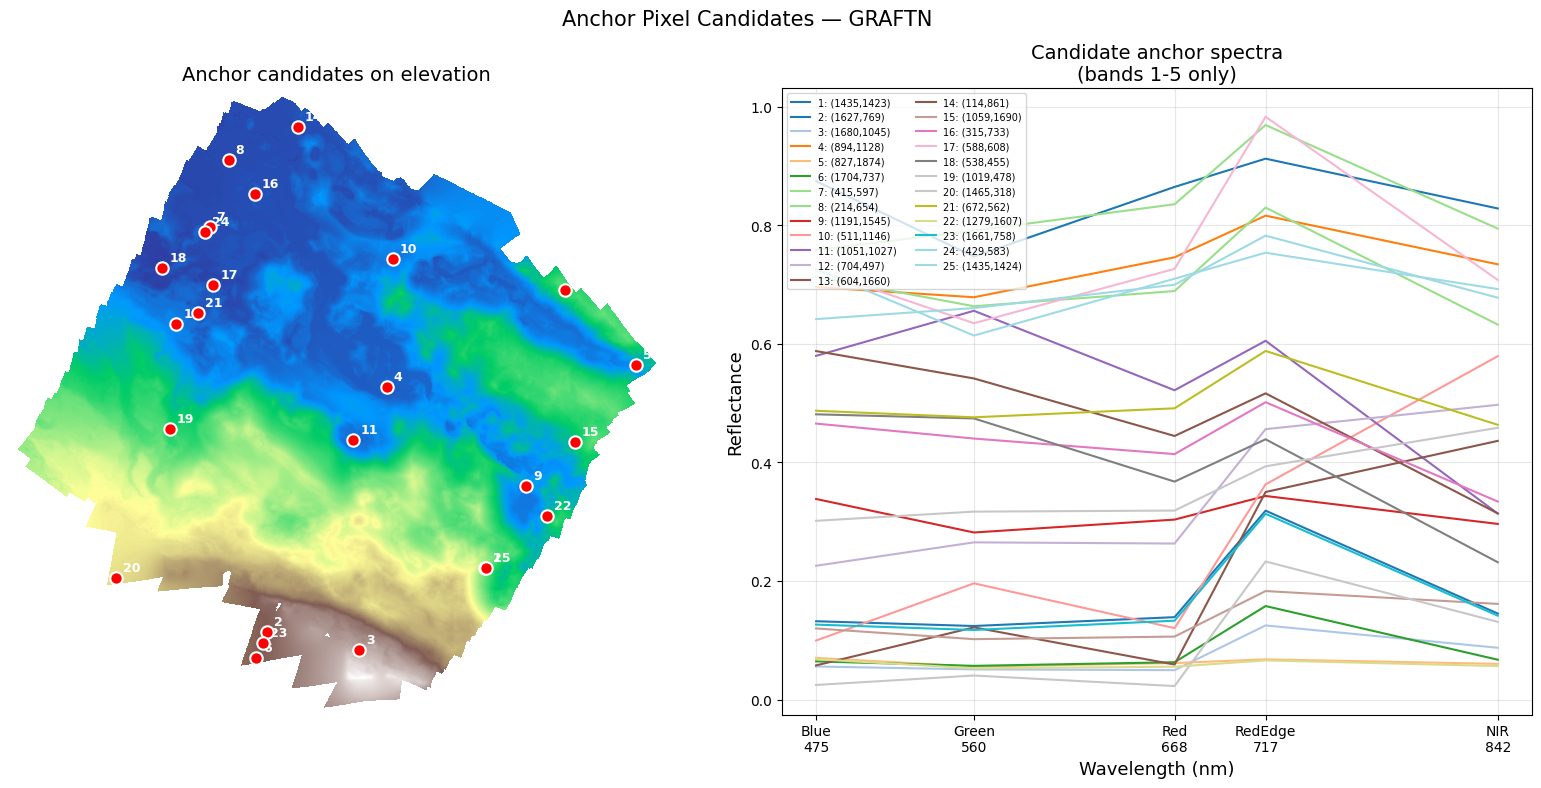

Saved anchor_candidates.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: elevation with anchor locations
elev_canvas = np.full((NROWS, NCOLS), np.nan)
elev_canvas[valid_r, valid_c] = np.load('data/node_features_topo.npy')[:, 0]

axes[0].imshow(elev_canvas, cmap='terrain', interpolation='nearest')
axes[0].scatter(anchor_cols, anchor_rows,
                c='red', s=80, zorder=5,
                edgecolors='white', linewidths=1.5)
for i, (r, c) in enumerate(zip(anchor_rows, anchor_cols)):
    axes[0].annotate(str(i+1), (c, r),
                     textcoords='offset points',
                     xytext=(5, 5),
                     fontsize=9, color='white',
                     fontweight='bold')
axes[0].set_title('Anchor candidates on elevation', fontsize=14)
axes[0].axis('off')

# Right: spectral signatures of all candidates
wavelengths = [475, 560, 668, 717, 842]
band_cols_plot = [0, 1, 2, 3, 4]   # Blue through NIR only for spectral plot

cmap_anchors = plt.cm.tab20(np.linspace(0, 1, len(selected)))

for i, (idx, color) in enumerate(zip(selected, cmap_anchors)):
    spectrum = spec7_valid[idx, :5]
    axes[1].plot(wavelengths, spectrum,
                 color=color, linewidth=1.5,
                 label=f'{i+1}: ({anchor_rows[i]},{anchor_cols[i]})')

axes[1].set_xlabel('Wavelength (nm)', fontsize=13)
axes[1].set_ylabel('Reflectance', fontsize=13)
axes[1].set_title('Candidate anchor spectra\n(bands 1-5 only)', fontsize=14)
axes[1].set_xticks(wavelengths)
axes[1].set_xticklabels(['Blue\n475', 'Green\n560', 'Red\n668',
                          'RedEdge\n717', 'NIR\n842'])
axes[1].legend(fontsize=7, ncol=2, loc='upper left')
axes[1].grid(alpha=0.3)

plt.suptitle('Anchor Pixel Candidates — GRAFTN', fontsize=15)
plt.tight_layout()
plt.savefig('anchor_candidates.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved anchor_candidates.png')

In [13]:
# export anchor candidates to geojson for ee
import json
from pyproj import Transformer

In [18]:
# check mosaic crs
print(f'mosaic crs: {crs}')

# transform from raster to crs to wgs84 (epg:4326) for ee
transformer = Transformer.from_crs(crs, 'epsg:4326', always_xy=True)
lons, lats = transformer.transform(
    anchor_df['x_coord'].values,
    anchor_df['y_coord'].values
)

anchor_df['lon'] = lons.round(7)
anchor_df['lat'] = lats.round(7)

# build geojson feature collection
features = []
for _, row in anchor_df.iterrows():
    feature = {
        'type': 'Feature',
        'geometry':{
            'type': 'Point',
            'coordinates': [row['lon'], row['lat']]
        },
        'properties': {
            'anchor_id' : int(row['anchor_id']),
            'row'       : int(row['row']),
            'col'       : int(row['col']),
            'Blue_475'   : float(row['Blue_475']),
            'Green_560'  : float(row['Green_560']),
            'Red_668'    : float(row['Red_668']),
            'RedEdge_717': float(row['RedEdge_717']),
            'NIR_842'    : float(row['NIR_842']),
            'Panc'       : float(row['Panc']),
            'LWIR_norm'  : float(row['LWIR_norm']),
        }
    }
    features.append(feature)

geojson = {
    'type' : 'FeatureCollection',
    'features': features
}

with open('data/anchor_candidates.geojson', 'w') as f:
    json.dump(geojson, f, indent=2)

# also save updated csv with lat/lon
anchor_df.to_csv('data/anchor_candidates_wgs84.csv',index=False)

print('Saved data/anchor_candidates.geojson')
print('Saved data/anchor_candidates_wgs84.csv')
print()
print('Lat/lon range:')
print(f'  Lon: [{lons.min():.5f}, {lons.max():.5f}]')
print(f'  Lat: [{lats.min():.5f}, {lats.max():.5f}]')
print()
print('Anchor locations (WGS84):')
print(f'{"ID":>4}  {"Lat":>12}  {"Lon":>12}  {"Row":>6}  {"Col":>6}')
print('-' * 44)
for _, row in anchor_df.iterrows():
    print(f'{int(row["anchor_id"]):>4}  '
          f'{row["lat"]:>12.6f}  '
          f'{row["lon"]:>12.6f}  '
          f'{int(row["row"]):>6}  '
          f'{int(row["col"]):>6}')

mosaic crs: EPSG:32606
Saved data/anchor_candidates.geojson
Saved data/anchor_candidates_wgs84.csv

Lat/lon range:
  Lon: [-145.66800, -145.63609]
  Lat: [63.35610, 63.37059]

Anchor locations (WGS84):
  ID           Lat           Lon     Row     Col
--------------------------------------------
   1     63.358426   -145.645522    1435    1423
   2     63.356799   -145.658897    1627     769
   3     63.356263   -145.653310    1680    1045
   4     63.363421   -145.651287     894    1128
   5     63.363888   -145.636092     827    1874
   6     63.356103   -145.659581    1704     737
   7     63.367894   -145.661879     415     597
   8     63.369718   -145.660635     214     654
   9     63.360630   -145.642937    1191    1545
  10     63.366913   -145.650757     511    1146
  11     63.362007   -145.653407    1051    1027
  12     63.365276   -145.664035     704     497
  13     63.365965   -145.640346     604    1660
  14     63.370591   -145.656383     114     861
  15     63.361806

In [20]:
# break time
# Save spec7_valid -- you'll need it for anchor extraction
np.save('data/spec7_valid.npy', spec7_valid)
np.save('data/anchor_pool_idx.npy', selected)
np.save('data/anchor_rows.npy', anchor_rows)
np.save('data/anchor_cols.npy', anchor_cols)

print('saved')

saved
